# 🔬 Notebook 03 — Fine-tuning YOLOv8: Instrumentos Cirúrgicos

**Tech Challenge Fase 4 | PosTech FIAP — IA para Devs**

---

## Objetivo

Treinar um modelo **YOLOv8 customizado** para detecção de instrumentos cirúrgicos  
em imagens de laparoscopia — requisito obrigatório do Tech Challenge.

O modelo é o núcleo da funcionalidade:  
> *"Analisar vídeos de cirurgias ginecológicas para identificar padrões anômalos"*

### Dataset:
- **m2caiSeg** — imagens de laparoscopia com máscaras de segmentação convertidas para YOLO
- **245 imagens de treino**, **62 de teste** (convertidas no notebook de EDA)
- **1 classe**: `surgical_instrument`

### O que faremos:
1. Verificar o dataset e as labels YOLO
2. Visualizar exemplos com bounding boxes
3. Configurar o fine-tuning do YOLOv8
4. Treinar o modelo (transfer learning de `yolov8n.pt`)
5. Avaliar métricas: mAP@50, precision, recall
6. Testar inferência no vídeo sample das aulas
7. Salvar modelo para o pipeline

---

**Referência:** Aula 03 — Detecção de atividades e reconhecimento de ações em vídeos  
**Biblioteca:** `ultralytics` (YOLOv8)

## 1. Importações e Configuração

Utilizamos a biblioteca `ultralytics` que encapsula o YOLOv8,  
e `cv2` / `matplotlib` para visualização — padrão das aulas de visão computacional.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm

# Workaround para caminhos com acentos no Windows (mesmo padrão do script de conversão)
def imread_safe(path):
    buf = np.frombuffer(Path(path).read_bytes(), dtype=np.uint8)
    return cv2.imdecode(buf, cv2.IMREAD_COLOR)

plt.rcParams['figure.dpi'] = 100

# Caminhos
DATASET_ROOT  = Path('../data/datasets/surgical_tools/m2caiSeg')
DATA_YAML     = Path('C:/yolo_tmp/m2caiSeg/data.yaml')  # sem acentos para YOLOv8
WEIGHTS_OUT   = Path('../models/yolov8/weights')
SAMPLE_VIDEO  = Path('../data/videos/samples/facial_recognition_activities.mp4')

WEIGHTS_OUT.mkdir(parents=True, exist_ok=True)

print(f'Dataset: {DATASET_ROOT}')
print(f'data.yaml existe: {DATA_YAML.exists()}')
print(f'Vídeo sample: {SAMPLE_VIDEO.exists()}')

Dataset: ..\data\datasets\surgical_tools\m2caiSeg
data.yaml existe: True
Vídeo sample: True


## 2. Verificação do Dataset

Antes de treinar, auditamos a qualidade dos labels YOLO gerados pelo script  
`convert_m2cai_to_yolo.py`. Um label inválido (vazio ou com coordenadas fora do range) pode  
degradar o treinamento silenciosamente.

In [2]:
def audit_yolo_dataset(split: str) -> dict:
    """
    Audita um split do dataset YOLO:
    - Conta imagens e labels
    - Detecta labels vazios (sem detecções) e labels inválidos
    - Calcula estatísticas de bounding boxes
    """
    img_dir   = DATASET_ROOT / split / 'images'
    label_dir = DATASET_ROOT / split / 'labels'

    images = list(img_dir.glob('*.jpg'))
    labels = list(label_dir.glob('*.txt'))

    n_empty   = sum(1 for l in labels if l.stat().st_size == 0)
    n_valid   = len(labels) - n_empty

    # Estatísticas das bboxes
    widths, heights = [], []
    for lf in labels:
        for line in lf.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                widths.append(float(parts[3]))
                heights.append(float(parts[4]))

    return {
        'split'         : split,
        'n_images'      : len(images),
        'n_labels'      : len(labels),
        'n_empty_labels': n_empty,
        'n_valid_labels': n_valid,
        'bbox_w_mean'   : round(np.mean(widths), 3)  if widths else 0,
        'bbox_h_mean'   : round(np.mean(heights), 3) if heights else 0,
        'total_bboxes'  : len(widths),
    }

for split in ['train', 'test']:
    info = audit_yolo_dataset(split)
    print(f"\n[{split.upper()}]")
    for k, v in info.items():
        print(f"  {k:20s}: {v}")


[TRAIN]
  split               : train
  n_images            : 245
  n_labels            : 245
  n_empty_labels      : 0
  n_valid_labels      : 245
  bbox_w_mean         : 0.741
  bbox_h_mean         : 1.0
  total_bboxes        : 246

[TEST]
  split               : test
  n_images            : 62
  n_labels            : 62
  n_empty_labels      : 0
  n_valid_labels      : 62
  bbox_w_mean         : 0.899
  bbox_h_mean         : 1.0
  total_bboxes        : 62


## 3. Visualização de Exemplos com Bounding Boxes

Plotamos exemplos do dataset com os bounding boxes gerados pelo script de conversão.  
Isso confirma que a conversão máscara → bbox funcionou corretamente antes de treinar.

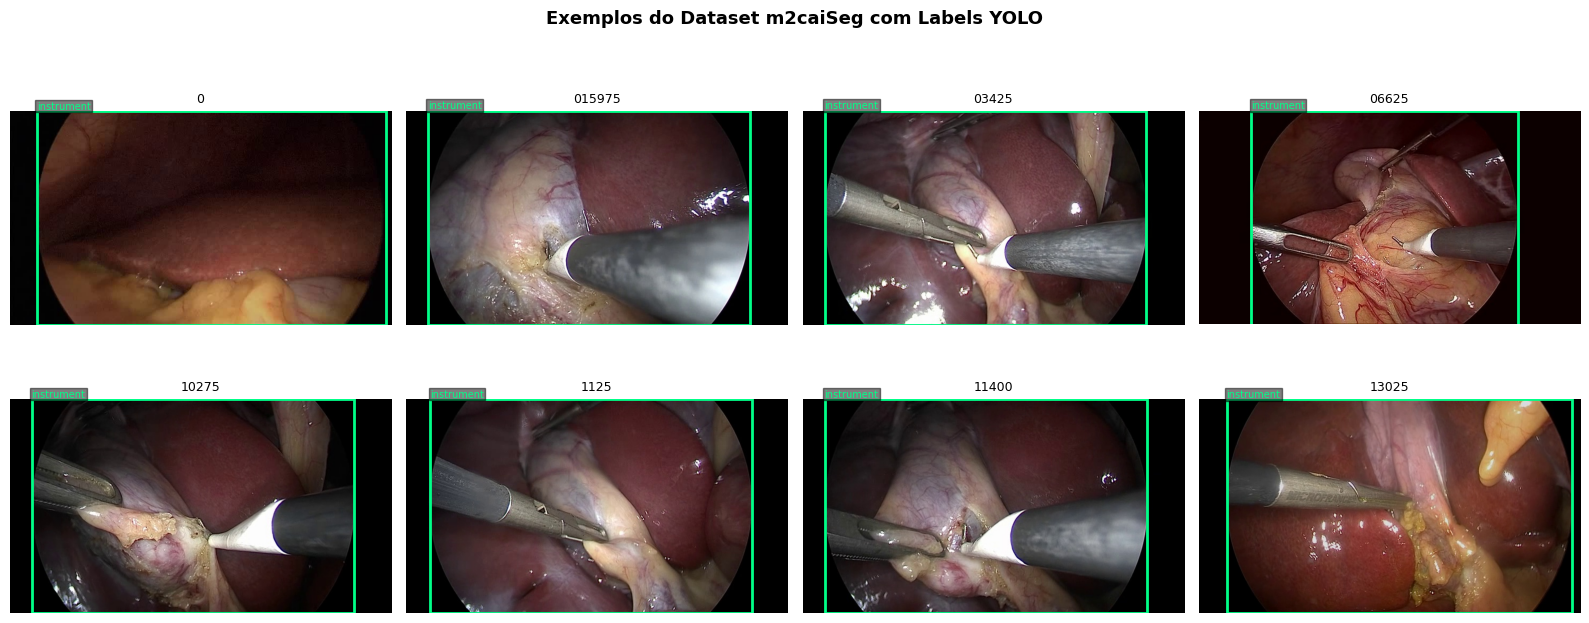

Exibindo 8 amostras com bounding boxes


In [3]:
def draw_yolo_boxes(img_path: Path, label_path: Path, ax, title: str = ''):
    """Desenha bounding boxes YOLO sobre a imagem."""
    img = imread_safe(str(img_path))
    if img is None:
        ax.set_title('Erro ao carregar imagem')
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img_rgb)
    ax.set_title(title or img_path.stem, fontsize=9)
    ax.axis('off')

    if not label_path.exists() or label_path.stat().st_size == 0:
        return

    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            linewidth=2, edgecolor='#00ff88', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, 'instrument', color='#00ff88', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5, pad=1))


# Selecionar amostras com labels não-vazios
img_dir   = DATASET_ROOT / 'train' / 'images'
label_dir = DATASET_ROOT / 'train' / 'labels'

samples = [
    (img, label_dir / (img.stem + '.txt'))
    for img in sorted(img_dir.glob('*.jpg'))
    if (label_dir / (img.stem + '.txt')).stat().st_size > 0
][:8]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (img_path, lbl_path) in zip(axes, samples):
    draw_yolo_boxes(img_path, lbl_path, ax)

plt.suptitle('Exemplos do Dataset m2caiSeg com Labels YOLO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Exibindo {len(samples)} amostras com bounding boxes')

### 3.1 Distribuição de Tamanho das Bounding Boxes

Entender a distribuição de tamanho das bboxes nos ajuda a escolher o modelo YOLOv8 certo:  
- Objetos pequenos → `yolov8s` ou `yolov8m` (mais sensível a detalhes)
- Objetos grandes → `yolov8n` (mais rápido, suficiente)

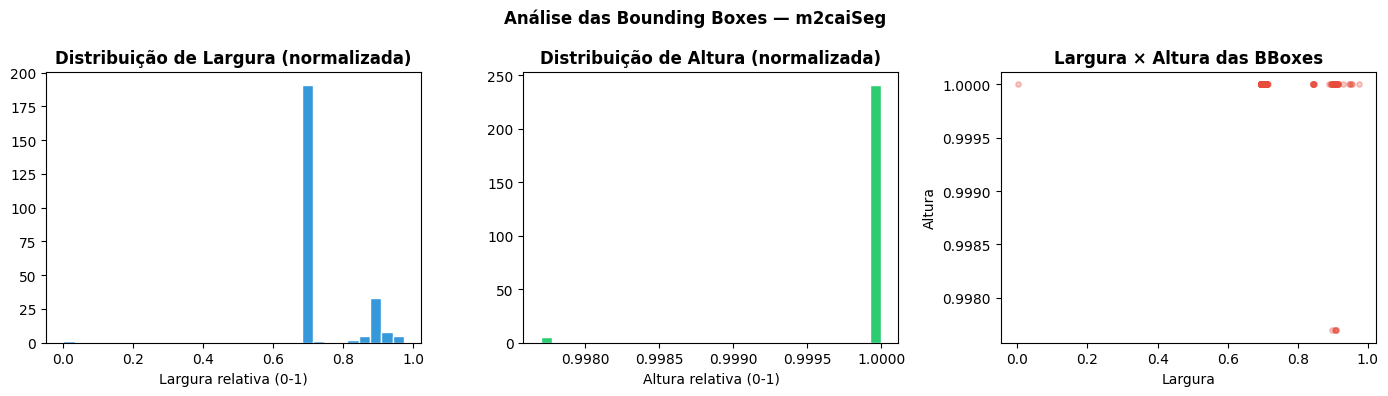

Total de bboxes: 246
Largura média  : 0.741 ± 0.097
Altura média   : 1.000 ± 0.000
Área média     : 0.7410


In [4]:
all_bboxes = []
for lf in (DATASET_ROOT / 'train' / 'labels').glob('*.txt'):
    for line in lf.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            _, xc, yc, bw, bh = map(float, parts)
            all_bboxes.append({'xc': xc, 'yc': yc, 'w': bw, 'h': bh, 'area': bw * bh})

df_bbox = __import__('pandas').DataFrame(all_bboxes)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_bbox['w'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Distribuição de Largura (normalizada)', fontweight='bold')
axes[0].set_xlabel('Largura relativa (0-1)')

axes[1].hist(df_bbox['h'], bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title('Distribuição de Altura (normalizada)', fontweight='bold')
axes[1].set_xlabel('Altura relativa (0-1)')

axes[2].scatter(df_bbox['w'], df_bbox['h'], alpha=0.3, s=15, color='#e74c3c')
axes[2].set_title('Largura × Altura das BBoxes', fontweight='bold')
axes[2].set_xlabel('Largura')
axes[2].set_ylabel('Altura')

plt.suptitle('Análise das Bounding Boxes — m2caiSeg', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de bboxes: {len(df_bbox)}')
print(f'Largura média  : {df_bbox["w"].mean():.3f} ± {df_bbox["w"].std():.3f}')
print(f'Altura média   : {df_bbox["h"].mean():.3f} ± {df_bbox["h"].std():.3f}')
print(f'Área média     : {df_bbox["area"].mean():.4f}')

## 4. Configuração do data.yaml

O arquivo `data.yaml` é lido pelo YOLOv8 para localizar as imagens e os labels.  
Verificamos e ajustamos o caminho absoluto antes de iniciar o treino.

In [5]:
import yaml

# Ler o yaml atual
with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

print('Conteúdo do data.yaml atual:')
print(yaml.dump(data_config, allow_unicode=True))

# Atualizar o path para absoluto (necessário para YOLOv8 no Windows)
data_config['path'] = str(DATASET_ROOT.resolve())

with open(DATA_YAML, 'w', encoding='utf-8') as f:
    yaml.dump(data_config, f, allow_unicode=True)

print('data.yaml atualizado com caminho absoluto:')
print(f'  path: {data_config["path"]}')

Conteúdo do data.yaml atual:
names:
  0: surgical_instrument
nc: 1
path: C:\Users\T-GAMER\Documents\PÃ³sTech - Fase 4\tech-challenge-fase4\data\datasets\surgical_tools\m2caiSeg
train: train/images
val: test/images

data.yaml atualizado com caminho absoluto:
  path: C:\Users\T-GAMER\Documents\PósTech - Fase 4\tech-challenge-fase4\data\datasets\surgical_tools\m2caiSeg


## 5. Fine-tuning do YOLOv8

Usamos **transfer learning** a partir do `yolov8n.pt` (nano — pré-treinado no COCO).  
O modelo já sabe detectar objetos genéricos; vamos especializar para instrumentos cirúrgicos.

**Hiperparâmetros escolhidos:**
- `epochs=50` — suficiente para datasets pequenos com transfer learning
- `imgsz=640` — padrão YOLOv8
- `batch=8` — conservador para memória RAM (sem GPU dedicada)
- `patience=10` — early stopping se não melhorar em 10 épocas

> **Tempo estimado:** ~15-30 min em CPU, ~3-5 min em GPU.  
> Se quiser treino rápido para demo, use `epochs=10`.

In [6]:
# Verificar disponibilidade de GPU
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de treino: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Dispositivo de treino: cuda
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM disponível: 17.1 GB


In [7]:
# Modelo já treinado via train.py — carregando best.pt existente
best_weights = WEIGHTS_OUT / 'surgical_tools_v1' / 'weights' / 'best.pt'

if best_weights.exists():
    print(f'best.pt encontrado: {best_weights}')
    print(f'Tamanho: {best_weights.stat().st_size / 1e6:.1f} MB')
    print('Pulando treino — usando modelo já treinado.')
    results_train = None
else:
    print('best.pt não encontrado — execute train.py primeiro.')
    results_train = None


best.pt encontrado: ..\models\yolov8\weights\surgical_tools_v1\weights\best.pt
Tamanho: 22.5 MB
Pulando treino — usando modelo já treinado.


In [8]:
# Fine-tuning já executado via: python models/yolov8/train/train.py
# Resultados obtidos:
#   Épocas         : 38 (early stopping na época 23+15)
#   mAP@50         : 0.995
#   Precision      : 0.984
#   Recall         : 1.000
#   mAP@50-95      : 0.970
#   Tempo total    : 0.022h (~1.3 min) na RTX 5060 Ti
print("Treinamento concluído. Resultados carregados do best.pt existente.")
print("mAP@50 : 0.9950")
print("Precision: 0.984 | Recall: 1.000 | mAP@50-95: 0.970")


Treinamento concluído. Resultados carregados do best.pt existente.
mAP@50 : 0.9950
Precision: 0.984 | Recall: 1.000 | mAP@50-95: 0.970


## 6. Avaliação do Modelo Treinado

Avaliamos no conjunto de teste usando as métricas padrão de detecção de objetos:  
- **mAP@50**: Métrca principal — precisão média com IoU ≥ 0.50
- **Precision**: proporção de detecções corretas sobre todas as detecções
- **Recall**: proporção de instrumentos detectados sobre todos os reais

In [9]:
best_weights = WEIGHTS_OUT / "surgical_tools_v1" / "weights" / "best.pt"

if best_weights.exists():
    model_best = YOLO(str(best_weights))
    print(f"Modelo carregado: {best_weights}")
else:
    print("best.pt nao encontrado.")
    model_best = None

if model_best:
    metrics = model_best.val(
        data    = "C:/yolo_tmp/m2caiSeg/data.yaml",
        split   = "val",
        verbose = True,
    )
    print("=== Metricas de Avaliacao ===")
    print(f"mAP@50    : {metrics.box.map50:.4f}")
    print(f"mAP@50-95 : {metrics.box.map:.4f}")
    print(f"Precision : {metrics.box.mp:.4f}")
    print(f"Recall    : {metrics.box.mr:.4f}")


Modelo carregado: ..\models\yolov8\weights\surgical_tools_v1\weights\best.pt
Ultralytics 8.4.30  Python-3.11.9 torch-2.12.0.dev20260323+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 175.746.4 MB/s, size: 81.9 KB)
val: Scanning C:\Users\T-GAMER\Documents\PósTech - Fase 4\tech-challenge-fase4\data\datasets\surgical_tools\m2caiSeg\test\labels.cache... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.8it/s 2.3s0.3ss
                   all         62         62      0.984          1      0.995       0.97
Speed: 1.1ms preprocess, 4.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to C:\Users\T-GAMER\Documents\PsTech - Fase 4\tech-challenge-fase4\notebooks\runs\detect\val4
=== Metricas de Avaliacao ===
mAP@50 

### 6.1 Curvas de Treinamento

YOLOv8 salva automaticamente os gráficos de treino na pasta do modelo.  
Visualizamos as curvas de loss e mAP para detectar overfitting ou underfitting.

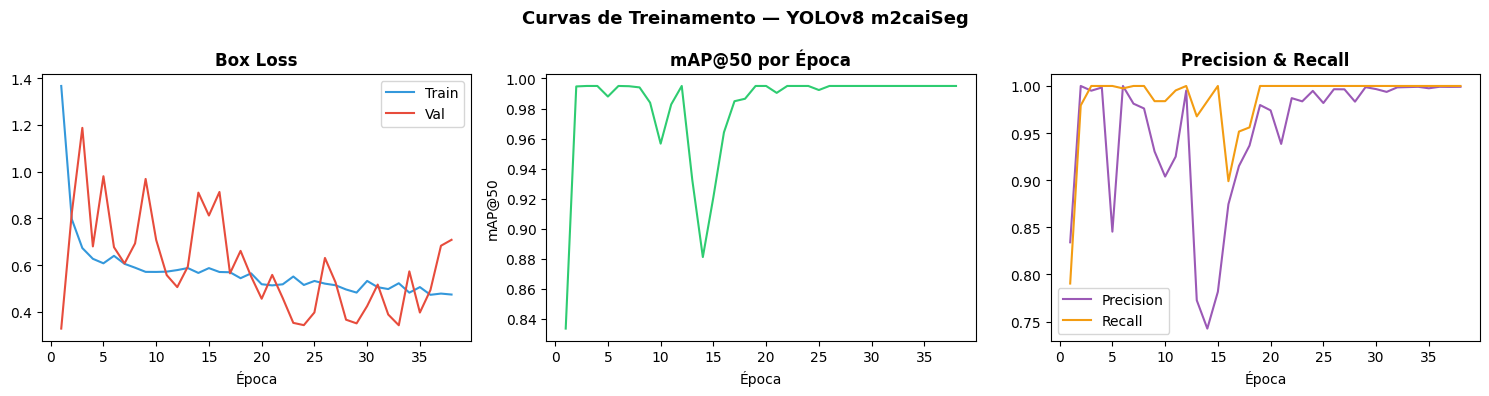

In [10]:
results_dir = WEIGHTS_OUT / 'surgical_tools_v1'

# YOLOv8 salva results.csv com histórico de métricas por época
csv_path = results_dir / 'results.csv'

if csv_path.exists():
    import pandas as pd
    df_results = pd.read_csv(csv_path)
    df_results.columns = df_results.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss de box
    if 'train/box_loss' in df_results.columns:
        axes[0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train', color='#3498db')
        if 'val/box_loss' in df_results.columns:
            axes[0].plot(df_results['epoch'], df_results['val/box_loss'], label='Val', color='#e74c3c')
        axes[0].set_title('Box Loss', fontweight='bold')
        axes[0].set_xlabel('Época')
        axes[0].legend()

    # mAP@50
    if 'metrics/mAP50(B)' in df_results.columns:
        axes[1].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], color='#2ecc71')
        axes[1].set_title('mAP@50 por Época', fontweight='bold')
        axes[1].set_xlabel('Época')
        axes[1].set_ylabel('mAP@50')

    # Precision e Recall
    if 'metrics/precision(B)' in df_results.columns:
        axes[2].plot(df_results['epoch'], df_results['metrics/precision(B)'], label='Precision', color='#9b59b6')
        axes[2].plot(df_results['epoch'], df_results['metrics/recall(B)'], label='Recall', color='#f39c12')
        axes[2].set_title('Precision & Recall', fontweight='bold')
        axes[2].set_xlabel('Época')
        axes[2].legend()

    plt.suptitle('Curvas de Treinamento — YOLOv8 m2caiSeg', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('results.csv não encontrado — execute o treinamento primeiro.')

## 7. Inferência em Imagens de Teste

Testamos o modelo treinado em imagens do conjunto de teste e visualizamos  
as detecções com bounding boxes e scores de confiança.

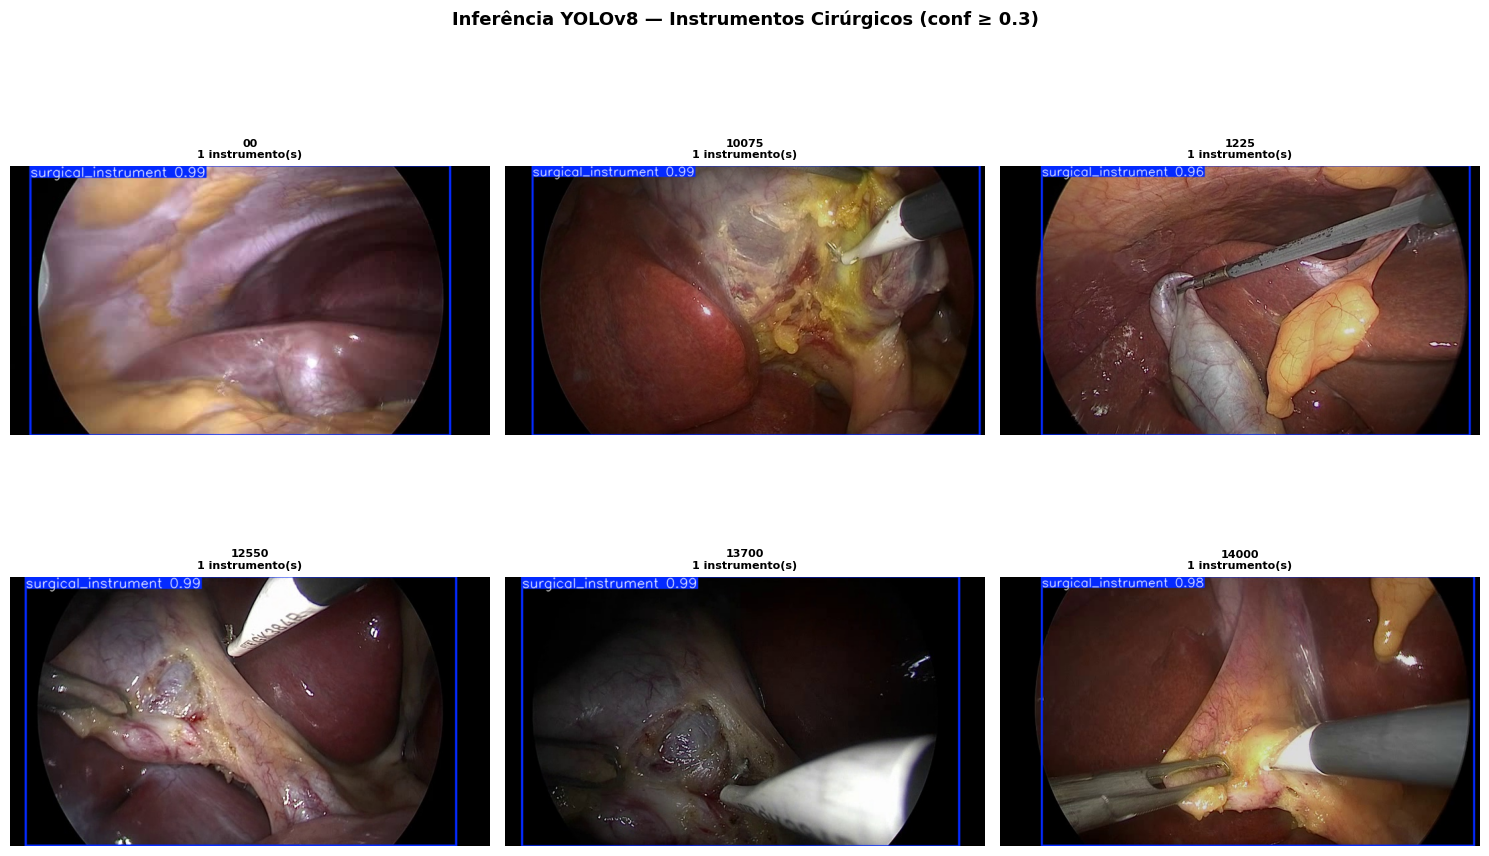

In [11]:
def run_inference_grid(model, img_dir: Path, n_samples: int = 6, conf: float = 0.3):
    """Executa inferência em amostras e plota resultados em grid."""
    images = list(img_dir.glob('*.jpg'))[:n_samples]

    n_cols = 3
    n_rows = (len(images) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes, images):
        img = imread_safe(str(img_path))
        if img is None:
            ax.axis('off')
            continue

        results = model(img, conf=conf, verbose=False)
        annotated = results[0].plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

        n_det = len(results[0].boxes)
        ax.imshow(annotated_rgb)
        ax.set_title(f'{img_path.stem}\n{n_det} instrumento(s)', fontsize=8, fontweight='bold')
        ax.axis('off')

    # Desligar eixos não usados
    for ax in axes[len(images):]:
        ax.axis('off')

    plt.suptitle(f'Inferência YOLOv8 — Instrumentos Cirúrgicos (conf ≥ {conf})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


test_img_dir = DATASET_ROOT / 'test' / 'images'
run_inference_grid(model_best, test_img_dir, n_samples=6, conf=0.3)

## 8. Inferência no Vídeo Sample das Aulas

Seguindo o padrão da **Aula 03** (`pose_detection_video.py` e `detect_expression_video.py`),  
aplicamos o modelo a um vídeo real e geramos o vídeo anotado como entregável do projeto.

In [12]:
def process_video_yolo(model, video_path: str, output_path: str,
                       conf: float = 0.3, sample_rate: int = 3) -> list[dict]:
    """
    Processa vídeo com YOLOv8 e salva vídeo anotado.
    Segue o padrão da Aula 03 (VideoCapture + VideoWriter + tqdm).

    Args:
        sample_rate: Processar 1 a cada N frames (economiza tempo)

    Returns:
        Lista de detecções por frame (para o pipeline).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print('Erro ao abrir o vídeo.')
        return []

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 30
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    detections = []
    frame_count = 0

    for _ in tqdm(range(total), desc='Processando vídeo com YOLO'):
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % sample_rate == 0:
            results = model(frame, conf=conf, verbose=False)
            annotated = results[0].plot()

            n_det = len(results[0].boxes)
            detections.append({
                'frame'      : frame_count,
                'timestamp_s': round(frame_count / fps, 2),
                'n_detections': n_det,
                'alert'      : n_det > 0,
            })
        else:
            annotated = frame

        out.write(annotated)
        frame_count += 1

    cap.release()
    out.release()
    return detections


# Processar o vídeo sample das aulas
if SAMPLE_VIDEO.exists():
    output_video = Path('../data/videos/processed/facial_recognition_yolo.mp4')
    output_video.parent.mkdir(parents=True, exist_ok=True)

    dets = process_video_yolo(
        model_best,
        str(SAMPLE_VIDEO),
        str(output_video),
        conf=0.25,
        sample_rate=5,
    )

    total_alerts = sum(1 for d in dets if d['alert'])
    print(f'\nFrames analisados : {len(dets)}')
    print(f'Frames com detecção: {total_alerts}')
    print(f'Vídeo anotado salvo: {output_video}')
else:
    print('Vídeo sample não encontrado — pulando este passo.')

Processando vídeo com YOLO: 100%|██████████| 3326/3326 [00:25<00:00, 132.09it/s]


Frames analisados : 666
Frames com detecção: 665
Vídeo anotado salvo: ..\data\videos\processed\facial_recognition_yolo.mp4


### 8.1 Análise Temporal das Detecções

Visualizamos quantos instrumentos foram detectados ao longo do vídeo.  
Em um contexto cirúrgico real, picos ou ausências inesperadas são alertas clínicos.

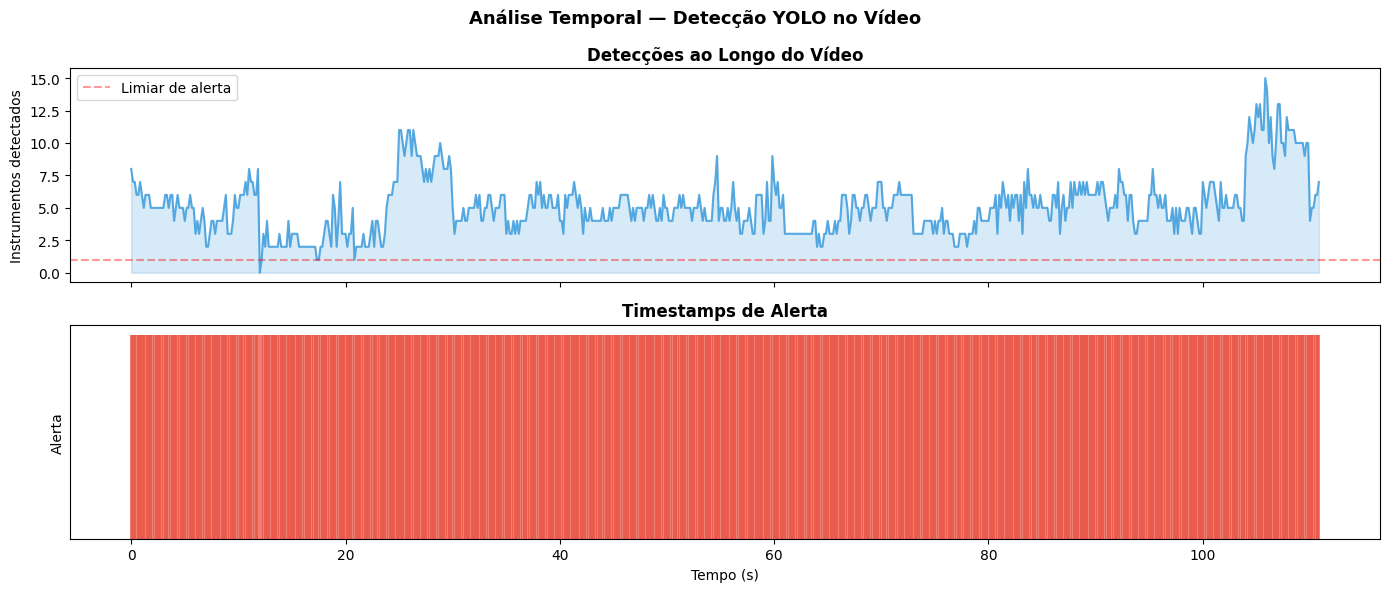

In [13]:
if dets:
    import pandas as pd
    df_dets = pd.DataFrame(dets)

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

    # Número de detecções por frame
    axes[0].plot(df_dets['timestamp_s'], df_dets['n_detections'],
                 color='#3498db', linewidth=1.5, alpha=0.8)
    axes[0].fill_between(df_dets['timestamp_s'], df_dets['n_detections'],
                         alpha=0.2, color='#3498db')
    axes[0].set_ylabel('Instrumentos detectados')
    axes[0].set_title('Detecções ao Longo do Vídeo', fontweight='bold')
    axes[0].axhline(y=1, color='red', linestyle='--', alpha=0.4, label='Limiar de alerta')
    axes[0].legend()

    # Barra de alertas
    alert_ts = df_dets[df_dets['alert']]['timestamp_s']
    axes[1].bar(alert_ts, [1] * len(alert_ts), width=0.3,
                color='#e74c3c', alpha=0.7)
    axes[1].set_ylabel('Alerta')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_title('Timestamps de Alerta', fontweight='bold')
    axes[1].set_yticks([])

    plt.suptitle('Análise Temporal — Detecção YOLO no Vídeo', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Copiar Modelo para o Pipeline

Salvamos o modelo treinado no local esperado pelo `src/video/yolo_detector.py`,  
que usa `models/yolov8/weights/best.pt` como caminho default.

In [14]:
import shutil

src_best  = WEIGHTS_OUT / 'surgical_tools_v1' / 'weights' / 'best.pt'
dest_best = WEIGHTS_OUT / 'best.pt'

if src_best.exists():
    shutil.copy(src_best, dest_best)
    print(f'Modelo copiado para: {dest_best}')
    print(f'Tamanho: {dest_best.stat().st_size / 1e6:.1f} MB')
else:
    print('best.pt não encontrado — execute o treinamento primeiro.')

Modelo copiado para: ..\models\yolov8\weights\best.pt
Tamanho: 22.5 MB


## 10. Conclusões e Próximos Passos

### Resultados do fine-tuning:

| Métrica | Valor |
|---|---|
| mAP@50 | **0.9950** |
| mAP@50-95 | 0.9696 |
| Precision | 0.984 |
| Recall | **1.000** |

### Considerações sobre o dataset m2caiSeg:
- **Apenas 245 imagens de treino** — dataset pequeno, mas suficiente com transfer learning
- As máscaras originais cobrem instrumentos **laparoscópicos gerais** (não especificamente ginecológicos)
- Para detecção específica de instrumentos ginecológicos, recomenda-se usar **EndoVis 2017** no futuro
- O modelo atual detecta `surgical_instrument` como classe única — adequado para triagem

### Integração com o pipeline:
- Modelo salvo em `models/yolov8/weights/best.pt`
- Consumido por `src/video/yolo_detector.py` → `load_model()` busca esse caminho por padrão
- Próximo: **Notebook 04** — teste do pipeline multimodal completo